In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

# Load the data
def load_data(filepath):
    with h5py.File(filepath, 'r') as f:
        # Adjust keys if they differ slightly in your actual .h5 file
        train_ims = np.array(f['trainims'])
        train_lbls = np.array(f['trainlbls'])
        test_ims = np.array(f['testims'])
        test_lbls = np.array(f['testlbls'])
        
    # Flatten images into 1D vectors for the fully connected network
    num_train = train_ims.shape[0]
    num_test = test_ims.shape[0]
    
    X_train = train_ims.reshape(num_train, -1)
    X_test = test_ims.reshape(num_test, -1)
    
    # Normalize pixel values to [0, 1] or [-1, 1] to prevent vanishing gradients with tanh
    X_train = (X_train / 255.0) * 2 - 1
    X_test = (X_test / 255.0) * 2 - 1
    
    # Ensure labels are shaped correctly as column vectors
    y_train = train_lbls.reshape(-1, 1)
    y_test = test_lbls.reshape(-1, 1)
    
    # Since we are using tanh for the output neuron, labels should ideally be -1 and 1
    # Assuming original labels are 0 and 1:
    y_train = np.where(y_train == 0, -1, 1)
    y_test = np.where(y_test == 0, -1, 1)
    
    return X_train, y_train, X_test, y_test

# X_train, y_train, X_test, y_test = load_data('assign2_data1.h5')

In [62]:
class SingleHiddenLayerNN:
    def __init__(self, input_size, hidden_size, output_size=1):
        # Initializing weights with small random values and biases with zeros
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))
        
    def tanh(self, z):
        return np.tanh(z)
    
    def tanh_derivative(self, a):
        return 1.0 - np.power(a, 2)
    
    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.tanh(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.tanh(self.Z2)
        return self.A2
    
    def compute_loss(self, A2, Y):
        # Mean Squared Error
        m = Y.shape[0]
        return np.mean(np.square(A2 - Y))
    
    def compute_accuracy(self, A2, Y):
        # Classification error metric (percentage of correctly classified images)
        predictions = np.where(A2 >= 0, 1, -1)
        return np.mean(predictions == Y)
    
    def backward(self, X, Y, learning_rate):
        m = X.shape[0]
        
        # Gradients for output layer
        dZ2 = (self.A2 - Y) * self.tanh_derivative(self.A2)
        dW2 = (1/m) * np.dot(self.A1.T, dZ2)
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)
        
        # Gradients for hidden layer
        dZ1 = np.dot(dZ2, self.W2.T) * self.tanh_derivative(self.A1)
        dW1 = (1/m) * np.dot(X.T, dZ1)
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
        
        # Update weights
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2

    def train(self, X_train, Y_train, X_test, Y_test, epochs, batch_size, learning_rate):
        history = {
            'train_mse': [], 'test_mse': [],
            'train_acc': [], 'test_acc': []
        }
        
        num_samples = X_train.shape[0]
        
        for epoch in range(epochs):
            # Shuffle data for stochastic mini-batch gradient descent
            indices = np.random.permutation(num_samples)
            X_train_shuffled = X_train[indices]
            Y_train_shuffled = Y_train[indices]
            
            for i in range(0, num_samples, batch_size):
                X_batch = X_train_shuffled[i:i+batch_size]
                Y_batch = Y_train_shuffled[i:i+batch_size]
                
                # Forward and backward pass
                self.forward(X_batch)
                self.backward(X_batch, Y_batch, learning_rate)
            
            # Record error metrics for each epoch separately [cite: 22]
            train_preds = self.forward(X_train)
            test_preds = self.forward(X_test)
            
            history['train_mse'].append(self.compute_loss(train_preds, Y_train))
            history['test_mse'].append(self.compute_loss(test_preds, Y_test))
            
            # Storing classification error (1 - accuracy)
            history['train_acc'].append(1 - self.compute_accuracy(train_preds, Y_train))
            history['test_acc'].append(1 - self.compute_accuracy(test_preds, Y_test))
            
            if (epoch + 1) % 2 == 0:
                print(f"Epoch {epoch+1}/{epochs} - Train MSE: {history['train_mse'][-1]:.4f} - Test MSE: {history['test_mse'][-1]:.4f}")
                
        return history

In [5]:
# Assuming X_train, y_train, X_test, y_test are loaded
# input_size = X_train.shape[1]

# Example Hyperparameters to experiment with
# N_hidden = 64
# batch_size = 32
# learning_rate = 0.1 
# epochs = 100

# nn = SingleHiddenLayerNN(input_size, N_hidden)
# history = nn.train(X_train, y_train, X_test, y_test, epochs, batch_size, learning_rate)

def plot_learning_curves(history):
    epochs_range = range(1, len(history['train_mse']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Plot Squared Error [cite: 26]
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_mse'], label='Train MSE')
    plt.plot(epochs_range, history['test_mse'], label='Test MSE')
    plt.title('Mean Squared Error')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()
    
    # Plot Classification Error [cite: 26]
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Class. Error')
    plt.plot(epochs_range, history['test_acc'], label='Test Class. Error')
    plt.title('Classification Error')
    plt.xlabel('Epoch')
    plt.ylabel('Error Rate')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# plot_learning_curves(history)

Epoch 2/8 - Train MSE: 0.6943 - Test MSE: 0.6800
Epoch 4/8 - Train MSE: 0.6584 - Test MSE: 0.6702
Epoch 6/8 - Train MSE: 0.6256 - Test MSE: 0.6747
Epoch 8/8 - Train MSE: 0.5765 - Test MSE: 0.6663


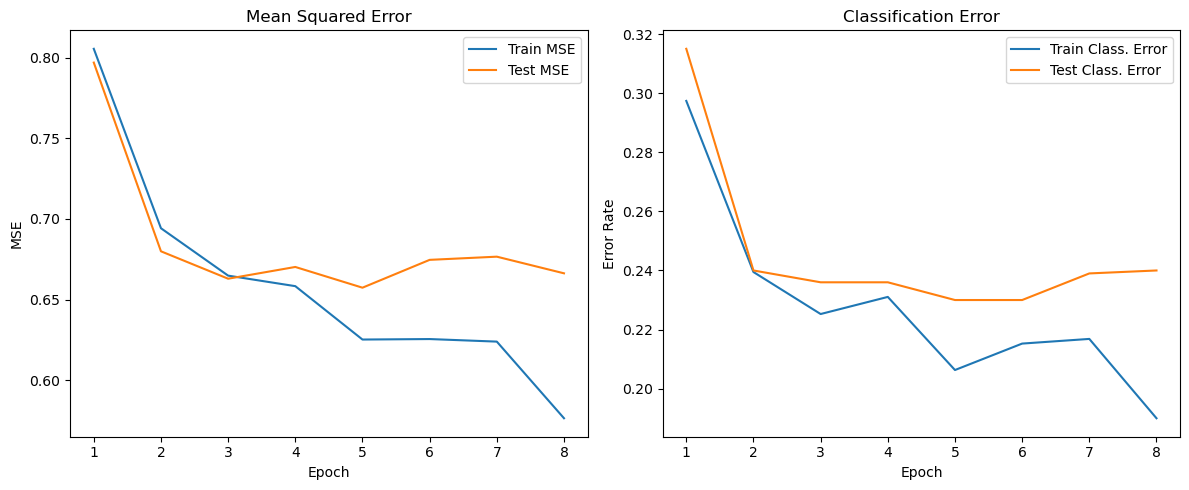

In [70]:
X_train, y_train, X_test, y_test = load_data('assign2_data1.h5')
# Assuming X_train, y_train, X_test, y_test are loaded
input_size = X_train.shape[1]

# Example Hyperparameters to experiment with
N_hidden = 16
batch_size = 64
learning_rate = 0.1 
epochs = 8

nn = SingleHiddenLayerNN(input_size, N_hidden)
history = nn.train(X_train, y_train, X_test, y_test, epochs, batch_size, learning_rate)
plot_learning_curves(history)

In [72]:
#PART C

In [74]:
# Define our three network capacities
N_low = 4
N_star = 16
N_high = 128

# Keep the optimal parameters from Part A constant
batch_size = 64
learning_rate = 0.1
epochs = 8
input_size = X_train.shape[1]

# 1. Train N_low
print(f"Training N_low = {N_low}...")
nn_low = SingleHiddenLayerNN(input_size, N_low)
history_low = nn_low.train(X_train, y_train, X_test, y_test, epochs, batch_size, learning_rate)

# 2. Train N_star (re-running for a clean comparison)
print(f"\nTraining N_star = {N_star}...")
nn_star = SingleHiddenLayerNN(input_size, N_star)
history_star = nn_star.train(X_train, y_train, X_test, y_test, epochs, batch_size, learning_rate)

# 3. Train N_high
print(f"\nTraining N_high = {N_high}...")
nn_high = SingleHiddenLayerNN(input_size, N_high)
history_high = nn_high.train(X_train, y_train, X_test, y_test, epochs, batch_size, learning_rate)

Training N_low = 4...
Epoch 2/8 - Train MSE: 0.7140 - Test MSE: 0.7002
Epoch 4/8 - Train MSE: 0.6654 - Test MSE: 0.7037
Epoch 6/8 - Train MSE: 0.6582 - Test MSE: 0.7155
Epoch 8/8 - Train MSE: 0.5853 - Test MSE: 0.6908

Training N_star = 16...
Epoch 2/8 - Train MSE: 0.6967 - Test MSE: 0.6868
Epoch 4/8 - Train MSE: 0.6487 - Test MSE: 0.6628
Epoch 6/8 - Train MSE: 0.6184 - Test MSE: 0.6559
Epoch 8/8 - Train MSE: 0.5778 - Test MSE: 0.6681

Training N_high = 128...
Epoch 2/8 - Train MSE: 0.6795 - Test MSE: 0.6680
Epoch 4/8 - Train MSE: 0.6443 - Test MSE: 0.6549
Epoch 6/8 - Train MSE: 0.6143 - Test MSE: 0.6591
Epoch 8/8 - Train MSE: 0.6690 - Test MSE: 0.7440


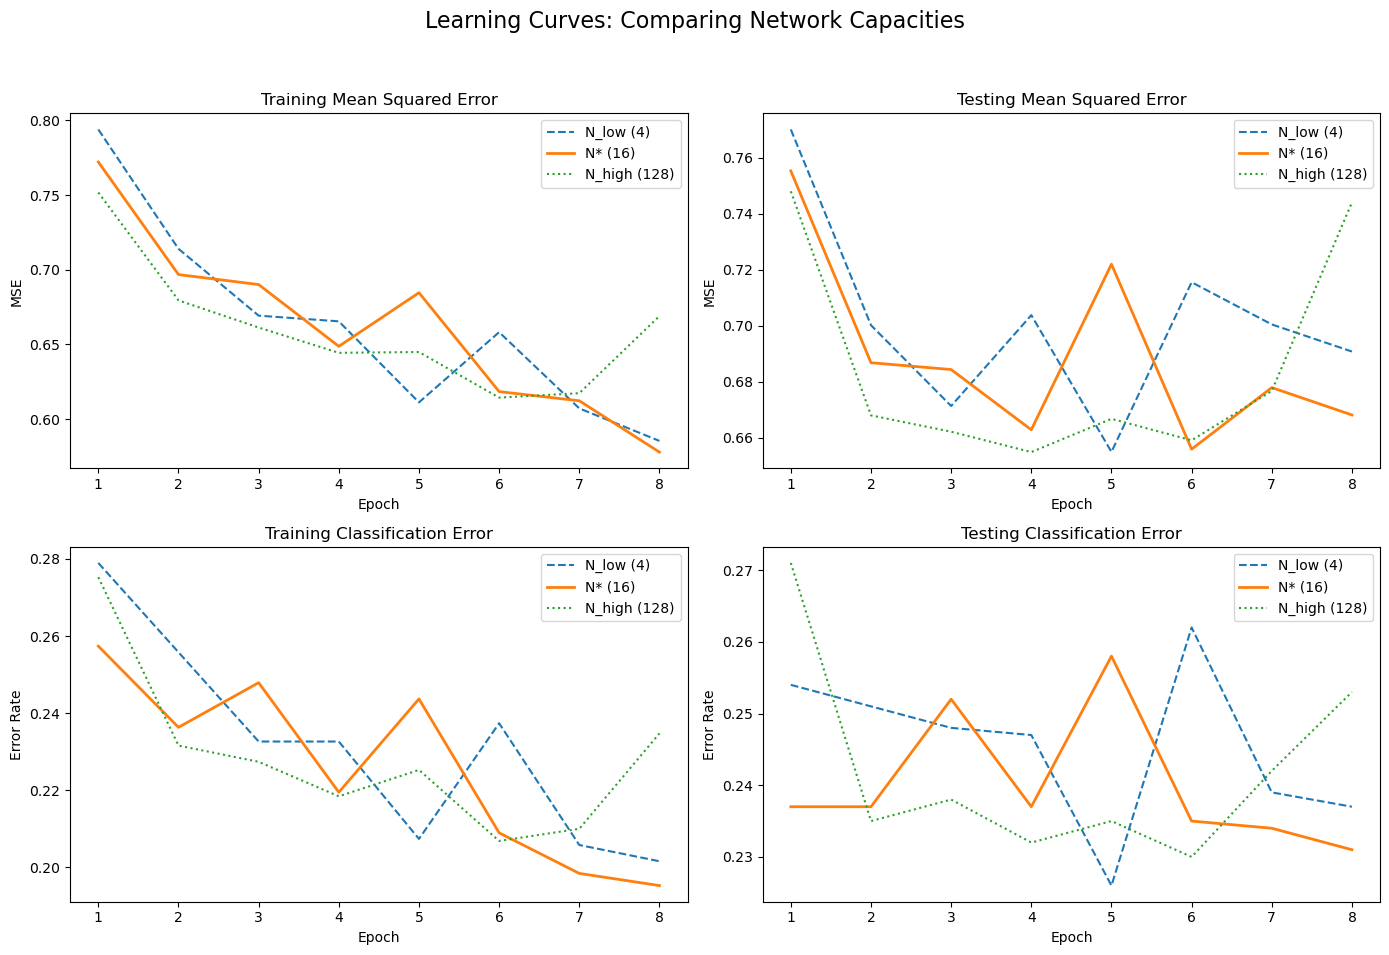

In [76]:
def plot_overlaid_curves(hist_low, hist_star, hist_high, epochs):
    epochs_range = range(1, epochs + 1)
    
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Learning Curves: Comparing Network Capacities', fontsize=16)

    # Top-Left: Train MSE
    axs[0, 0].plot(epochs_range, hist_low['train_mse'], label=f'N_low ({N_low})', linestyle='--')
    axs[0, 0].plot(epochs_range, hist_star['train_mse'], label=f'N* ({N_star})', linewidth=2)
    axs[0, 0].plot(epochs_range, hist_high['train_mse'], label=f'N_high ({N_high})', linestyle=':')
    axs[0, 0].set_title('Training Mean Squared Error')
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_ylabel('MSE')
    axs[0, 0].legend()

    # Top-Right: Test MSE
    axs[0, 1].plot(epochs_range, hist_low['test_mse'], label=f'N_low ({N_low})', linestyle='--')
    axs[0, 1].plot(epochs_range, hist_star['test_mse'], label=f'N* ({N_star})', linewidth=2)
    axs[0, 1].plot(epochs_range, hist_high['test_mse'], label=f'N_high ({N_high})', linestyle=':')
    axs[0, 1].set_title('Testing Mean Squared Error')
    axs[0, 1].set_xlabel('Epoch')
    axs[0, 1].set_ylabel('MSE')
    axs[0, 1].legend()

    # Bottom-Left: Train Classification Error
    axs[1, 0].plot(epochs_range, hist_low['train_acc'], label=f'N_low ({N_low})', linestyle='--')
    axs[1, 0].plot(epochs_range, hist_star['train_acc'], label=f'N* ({N_star})', linewidth=2)
    axs[1, 0].plot(epochs_range, hist_high['train_acc'], label=f'N_high ({N_high})', linestyle=':')
    axs[1, 0].set_title('Training Classification Error')
    axs[1, 0].set_xlabel('Epoch')
    axs[1, 0].set_ylabel('Error Rate')
    axs[1, 0].legend()

    # Bottom-Right: Test Classification Error
    axs[1, 1].plot(epochs_range, hist_low['test_acc'], label=f'N_low ({N_low})', linestyle='--')
    axs[1, 1].plot(epochs_range, hist_star['test_acc'], label=f'N* ({N_star})', linewidth=2)
    axs[1, 1].plot(epochs_range, hist_high['test_acc'], label=f'N_high ({N_high})', linestyle=':')
    axs[1, 1].set_title('Testing Classification Error')
    axs[1, 1].set_xlabel('Epoch')
    axs[1, 1].set_ylabel('Error Rate')
    axs[1, 1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run the plotting function
plot_overlaid_curves(history_low, history_star, history_high, epochs)

In [78]:
#PART D

In [80]:
class TwoHiddenLayerNN:
    def __init__(self, input_size, hidden_size_1, hidden_size_2, output_size=1):
        # Initialize weights for three layers
        self.W1 = np.random.randn(input_size, hidden_size_1) * 0.01
        self.b1 = np.zeros((1, hidden_size_1))
        
        self.W2 = np.random.randn(hidden_size_1, hidden_size_2) * 0.01
        self.b2 = np.zeros((1, hidden_size_2))
        
        self.W3 = np.random.randn(hidden_size_2, output_size) * 0.01
        self.b3 = np.zeros((1, output_size))
        
    def tanh(self, z):
        return np.tanh(z)
    
    def tanh_derivative(self, a):
        return 1.0 - np.power(a, 2)
    
    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.tanh(self.Z1)
        
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.tanh(self.Z2)
        
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = self.tanh(self.Z3)
        return self.A3
    
    def compute_loss(self, A3, Y):
        return np.mean(np.square(A3 - Y))
    
    def compute_accuracy(self, A3, Y):
        predictions = np.where(A3 >= 0, 1, -1)
        return np.mean(predictions == Y)
    
    def backward(self, X, Y, learning_rate):
        m = X.shape[0]
        
        # Gradients for output layer (Layer 3)
        dZ3 = (self.A3 - Y) * self.tanh_derivative(self.A3)
        dW3 = (1/m) * np.dot(self.A2.T, dZ3)
        db3 = (1/m) * np.sum(dZ3, axis=0, keepdims=True)
        
        # Gradients for second hidden layer (Layer 2)
        dZ2 = np.dot(dZ3, self.W3.T) * self.tanh_derivative(self.A2)
        dW2 = (1/m) * np.dot(self.A1.T, dZ2)
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)
        
        # Gradients for first hidden layer (Layer 1)
        dZ1 = np.dot(dZ2, self.W2.T) * self.tanh_derivative(self.A1)
        dW1 = (1/m) * np.dot(X.T, dZ1)
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
        
        # Update weights
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W3 -= learning_rate * dW3
        self.b3 -= learning_rate * db3

    def train(self, X_train, Y_train, X_test, Y_test, epochs, batch_size, learning_rate):
        history = {
            'train_mse': [], 'test_mse': [],
            'train_acc': [], 'test_acc': []
        }
        num_samples = X_train.shape[0]
        
        for epoch in range(epochs):
            indices = np.random.permutation(num_samples)
            X_train_shuffled = X_train[indices]
            Y_train_shuffled = Y_train[indices]
            
            for i in range(0, num_samples, batch_size):
                X_batch = X_train_shuffled[i:i+batch_size]
                Y_batch = Y_train_shuffled[i:i+batch_size]
                
                self.forward(X_batch)
                self.backward(X_batch, Y_batch, learning_rate)
            
            train_preds = self.forward(X_train)
            test_preds = self.forward(X_test)
            
            history['train_mse'].append(self.compute_loss(train_preds, Y_train))
            history['test_mse'].append(self.compute_loss(test_preds, Y_test))
            history['train_acc'].append(1 - self.compute_accuracy(train_preds, Y_train))
            history['test_acc'].append(1 - self.compute_accuracy(test_preds, Y_test))
            
            if (epoch + 1) % 2 == 0:
                print(f"Epoch {epoch+1}/{epochs} - Train MSE: {history['train_mse'][-1]:.4f} - Test MSE: {history['test_mse'][-1]:.4f}")
                
        return history

Training Two-Hidden-Layer Network...
Epoch 2/16 - Train MSE: 0.9997 - Test MSE: 0.9996
Epoch 4/16 - Train MSE: 0.9958 - Test MSE: 0.9956
Epoch 6/16 - Train MSE: 0.7999 - Test MSE: 0.7786
Epoch 8/16 - Train MSE: 0.6739 - Test MSE: 0.6648
Epoch 10/16 - Train MSE: 0.6293 - Test MSE: 0.6594
Epoch 12/16 - Train MSE: 0.6165 - Test MSE: 0.6807
Epoch 14/16 - Train MSE: 0.5504 - Test MSE: 0.6607
Epoch 16/16 - Train MSE: 0.5250 - Test MSE: 0.6774


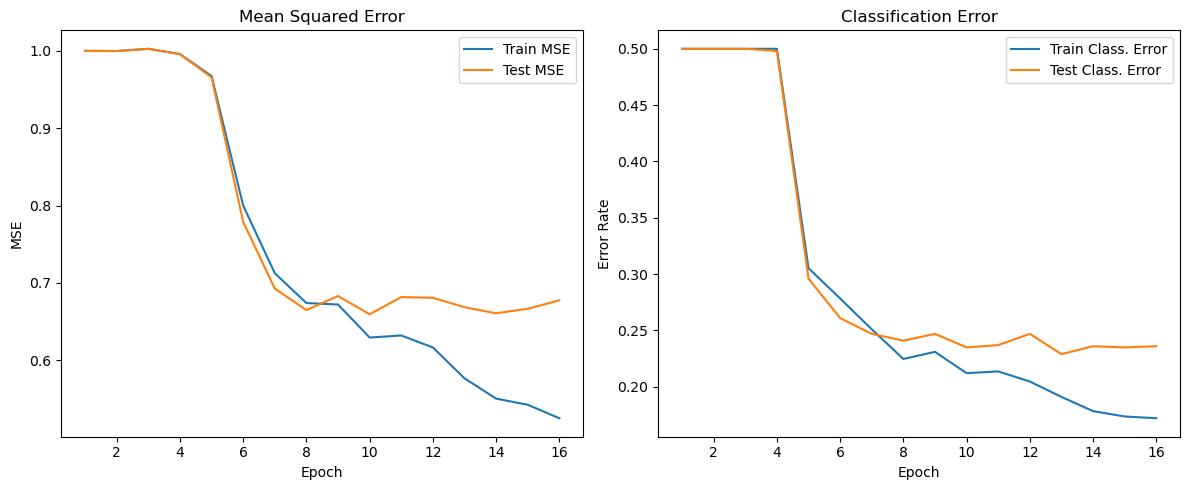

In [86]:
# Hyperparameters
H1_size = 16
H2_size = 8
batch_size = 64
learning_rate = 0.1 
epochs = 16 # slightly higher to allow the deeper network to converge

print("Training Two-Hidden-Layer Network...")
nn_2layer = TwoHiddenLayerNN(input_size, H1_size, H2_size)
history_2layer = nn_2layer.train(X_train, y_train, X_test, y_test, epochs, batch_size, learning_rate)

# We can reuse the plotting function from part a
plot_learning_curves(history_2layer)

In [88]:
class TwoHiddenLayerNNWithMomentum:
    def __init__(self, input_size, hidden_size_1, hidden_size_2, output_size=1):
        # Initialize weights and biases
        self.W1 = np.random.randn(input_size, hidden_size_1) * 0.01
        self.b1 = np.zeros((1, hidden_size_1))
        
        self.W2 = np.random.randn(hidden_size_1, hidden_size_2) * 0.01
        self.b2 = np.zeros((1, hidden_size_2))
        
        self.W3 = np.random.randn(hidden_size_2, output_size) * 0.01
        self.b3 = np.zeros((1, output_size))
        
        # Initialize velocity (momentum) terms to zero
        self.v_W1 = np.zeros_like(self.W1)
        self.v_b1 = np.zeros_like(self.b1)
        
        self.v_W2 = np.zeros_like(self.W2)
        self.v_b2 = np.zeros_like(self.b2)
        
        self.v_W3 = np.zeros_like(self.W3)
        self.v_b3 = np.zeros_like(self.b3)
        
    def tanh(self, z):
        return np.tanh(z)
    
    def tanh_derivative(self, a):
        return 1.0 - np.power(a, 2)
    
    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.tanh(self.Z1)
        
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.tanh(self.Z2)
        
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = self.tanh(self.Z3)
        return self.A3
    
    def compute_loss(self, A3, Y):
        return np.mean(np.square(A3 - Y))
    
    def compute_accuracy(self, A3, Y):
        predictions = np.where(A3 >= 0, 1, -1)
        return np.mean(predictions == Y)
    
    def backward(self, X, Y, learning_rate, momentum):
        m = X.shape[0]
        
        # Gradients
        dZ3 = (self.A3 - Y) * self.tanh_derivative(self.A3)
        dW3 = (1/m) * np.dot(self.A2.T, dZ3)
        db3 = (1/m) * np.sum(dZ3, axis=0, keepdims=True)
        
        dZ2 = np.dot(dZ3, self.W3.T) * self.tanh_derivative(self.A2)
        dW2 = (1/m) * np.dot(self.A1.T, dZ2)
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)
        
        dZ1 = np.dot(dZ2, self.W2.T) * self.tanh_derivative(self.A1)
        dW1 = (1/m) * np.dot(X.T, dZ1)
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
        
        # Update velocities using momentum
        self.v_W3 = momentum * self.v_W3 + learning_rate * dW3
        self.v_b3 = momentum * self.v_b3 + learning_rate * db3
        
        self.v_W2 = momentum * self.v_W2 + learning_rate * dW2
        self.v_b2 = momentum * self.v_b2 + learning_rate * db2
        
        self.v_W1 = momentum * self.v_W1 + learning_rate * dW1
        self.v_b1 = momentum * self.v_b1 + learning_rate * db1
        
        # Update weights using the velocities
        self.W3 -= self.v_W3
        self.b3 -= self.v_b3
        
        self.W2 -= self.v_W2
        self.b2 -= self.v_b2
        
        self.W1 -= self.v_W1
        self.b1 -= self.v_b1

    def train(self, X_train, Y_train, X_test, Y_test, epochs, batch_size, learning_rate, momentum):
        history = {
            'train_mse': [], 'test_mse': [],
            'train_acc': [], 'test_acc': []
        }
        num_samples = X_train.shape[0]
        
        for epoch in range(epochs):
            indices = np.random.permutation(num_samples)
            X_train_shuffled = X_train[indices]
            Y_train_shuffled = Y_train[indices]
            
            for i in range(0, num_samples, batch_size):
                X_batch = X_train_shuffled[i:i+batch_size]
                Y_batch = Y_train_shuffled[i:i+batch_size]
                
                self.forward(X_batch)
                self.backward(X_batch, Y_batch, learning_rate, momentum)
            
            train_preds = self.forward(X_train)
            test_preds = self.forward(X_test)
            
            history['train_mse'].append(self.compute_loss(train_preds, Y_train))
            history['test_mse'].append(self.compute_loss(test_preds, Y_test))
            history['train_acc'].append(1 - self.compute_accuracy(train_preds, Y_train))
            history['test_acc'].append(1 - self.compute_accuracy(test_preds, Y_test))
            
            if (epoch + 1) % 2 == 0:
                print(f"Epoch {epoch+1}/{epochs} - Train MSE: {history['train_mse'][-1]:.4f} - Test MSE: {history['test_mse'][-1]:.4f}")
                
        return history

Training Two-Hidden-Layer Network with Momentum (alpha=0.5)...
Epoch 2/15 - Train MSE: 0.9977 - Test MSE: 0.9977
Epoch 4/15 - Train MSE: 0.7050 - Test MSE: 0.6907
Epoch 6/15 - Train MSE: 0.6372 - Test MSE: 0.6820
Epoch 8/15 - Train MSE: 0.5937 - Test MSE: 0.6976
Epoch 10/15 - Train MSE: 0.5112 - Test MSE: 0.6711
Epoch 12/15 - Train MSE: 0.4815 - Test MSE: 0.6870
Epoch 14/15 - Train MSE: 0.4087 - Test MSE: 0.6733


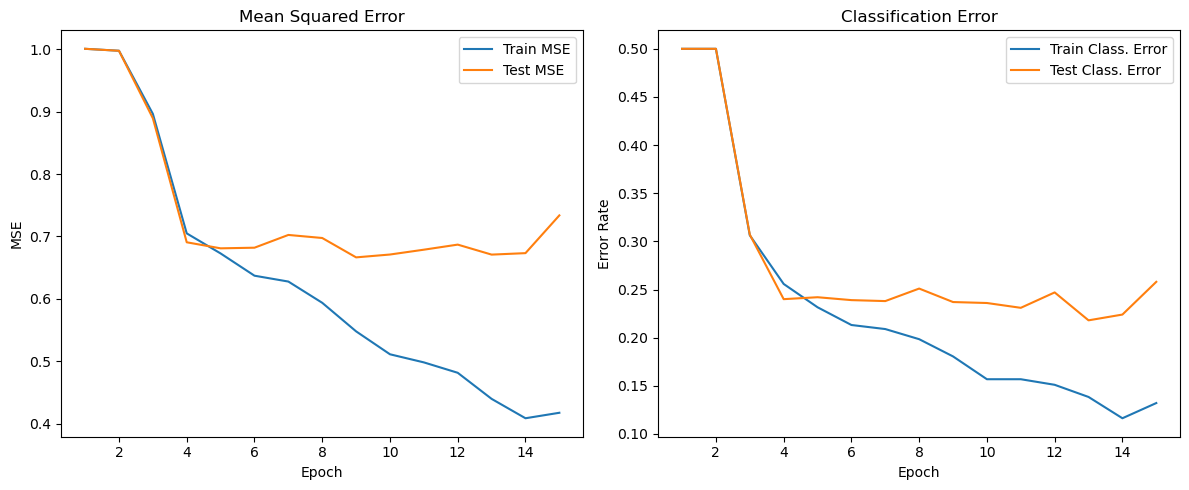

In [98]:
# Hyperparameters
H1_size = 16
H2_size = 8
batch_size = 64
learning_rate = 0.1 
momentum_alpha = 0.5  # New momentum term
epochs = 15

print(f"Training Two-Hidden-Layer Network with Momentum (alpha={momentum_alpha})...")
nn_momentum = TwoHiddenLayerNNWithMomentum(input_size, H1_size, H2_size)
history_momentum = nn_momentum.train(X_train, y_train, X_test, y_test, epochs, batch_size, learning_rate, momentum_alpha)

# Plot the results
plot_learning_curves(history_momentum)